# S&P 500 Overnight Carry vs Buy-and-Hold Backtest

This notebook compares a simple **overnight carry** strategy on the S&P 500 proxy ETF (**SPY**) against a **buy-and-hold** benchmark.

## Definitions
- **Buy-and-hold daily return**: close-to-close return.
- **Overnight carry return**: previous close to next open return, i.e. holding exposure only overnight.

## Notes
- SPY is used as a liquid tradable proxy for the S&P 500.
- Returns exclude transaction costs, slippage, financing, and taxes.
- Adjusted close is used for buy-and-hold total-return consistency, while raw open is used for the overnight leg.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [15]:
import importlib.util

if importlib.util.find_spec('yfinance') is None:
    %pip install yfinance -q

import yfinance as yf

In [6]:
# Download long-run SPY history
symbol = 'SPY'
start_date = '1993-01-01'

raw = yf.download(symbol, start=start_date, auto_adjust=False, progress=False)
if raw.empty:
    raise ValueError('No data downloaded for SPY.')

# Handle possible multi-index columns from yfinance
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

data = raw[['Open', 'Close', 'Adj Close', 'Volume']].copy()
data = data.dropna().sort_index()

data['buy_hold_return'] = data['Adj Close'].pct_change()
data['overnight_return'] = data['Open'] / data['Close'].shift(1) - 1
# Optional decomposition check: intraday open-to-close return
data['intraday_return'] = data['Close'] / data['Open'] - 1

data = data.dropna().copy()

data[['Open', 'Close', 'Adj Close', 'buy_hold_return', 'overnight_return', 'intraday_return']].head()

/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Price,Open,Close,Adj Close,buy_hold_return,overnight_return,intraday_return
Date,,,,,,
1993-02-01,43.968750,44.250000,24.347328,0.007113,0.000711,0.006397
1993-02-02,44.218750,44.343750,24.398907,0.002118,-0.000706,0.002827
1993-02-03,44.406250,44.812500,24.656836,0.010571,0.001409,0.009148
1993-02-04,44.968750,45.000000,24.759991,0.004184,0.003487,0.000695
1993-02-05,44.968750,44.968750,24.742800,-0.000694,-0.000694,0.000000


In [7]:
data

Price,Open,Close,Adj Close,Volume,buy_hold_return,overnight_return,intraday_return
Date,,,,,,,
1993-02-01,43.968750,44.250000,24.347328,480500,0.007113,0.000711,0.006397
1993-02-02,44.218750,44.343750,24.398907,201300,0.002118,-0.000706,0.002827
1993-02-03,44.406250,44.812500,24.656836,529400,0.010571,0.001409,0.009148
1993-02-04,44.968750,45.000000,24.759991,531500,0.004184,0.003487,0.000695
1993-02-05,44.968750,44.968750,24.742800,492100,-0.000694,-0.000694,0.000000
...,...,...,...,...,...,...,...
2026-04-13,677.409973,686.099976,686.099976,54185800,0.009772,-0.003017,0.012828
2026-04-14,687.690002,694.460022,694.460022,63480500,0.012185,0.002317,0.009845
2026-04-15,695.260010,699.940002,699.940002,58240400,0.007891,0.001152,0.006731


In [8]:
# Build cumulative performance series
initial_capital = 1.0

performance = pd.DataFrame(index=data.index)
performance['Buy & Hold'] = initial_capital * (1 + data['buy_hold_return']).cumprod()
performance['Overnight Carry'] = initial_capital * (1 + data['overnight_return']).cumprod()
performance['Intraday Only'] = initial_capital * (1 + data['intraday_return']).cumprod()

performance.tail()

,Buy & Hold,Overnight Carry,Intraday Only
Date,,,
2026-04-13,28.380113,12.449050,1.254342
2026-04-14,28.725921,12.477900,1.266690
2026-04-15,28.952597,12.492274,1.275217
2026-04-16,29.023743,12.512264,1.276308
2026-04-17,29.374514,12.592153,1.283538


In [13]:
# Summary statistics
trading_days = 252
period_years = (performance.index[-1] - performance.index[0]).days / 365.25


def max_drawdown(equity_curve: pd.Series) -> float:
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown.min()


def summarize_strategy(return_series: pd.Series, equity_curve: pd.Series) -> pd.Series:
    total_return = equity_curve.iloc[-1] / equity_curve.iloc[0] - 1
    cagr = equity_curve.iloc[-1] ** (1 / period_years) - 1
    annual_vol = return_series.std() * np.sqrt(trading_days)
    sharpe = np.nan if annual_vol == 0 else return_series.mean() / return_series.std() * np.sqrt(trading_days)
    
    # Sortino Ratio (using downside returns)
    downside_returns = return_series[return_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(trading_days)
    sortino = np.nan if pd.isna(downside_vol) or downside_vol == 0 else (return_series.mean() * trading_days) / downside_vol
    
    # Calmar Ratio
    mdd = max_drawdown(equity_curve)
    calmar = np.nan if mdd == 0 else cagr / abs(mdd)
    
    # Value at Risk (VaR 95%) and Conditional VaR (CVaR 95%)
    var_95 = return_series.quantile(0.05)
    cvar_95 = return_series[return_series <= var_95].mean()
    
    return pd.Series({
        'Start': equity_curve.index[0].strftime('%Y-%m-%d'),
        'End': equity_curve.index[-1].strftime('%Y-%m-%d'),
        'Years': period_years,
        'Total Return': total_return,
        'CAGR': cagr,
        'Annual Volatility': annual_vol,
        'Sharpe (rf=0)': sharpe,
        'Sortino (rf=0)': sortino,
        'Max Drawdown': mdd,
        'Calmar Ratio': calmar,
        'VaR (95%)': var_95,
        'CVaR (95%)': cvar_95,
        'Skewness': return_series.skew(),
        'Kurtosis': return_series.kurtosis(),
        'Win Rate': (return_series > 0).mean(),
        'Avg Daily Return': return_series.mean(),
        'Median Daily Return': return_series.median(),
    })

summary = pd.DataFrame({
    'Buy & Hold': summarize_strategy(data['buy_hold_return'], performance['Buy & Hold']),
    'Overnight Carry': summarize_strategy(data['overnight_return'], performance['Overnight Carry']),
    'Intraday Only': summarize_strategy(data['intraday_return'], performance['Intraday Only']),
}).T

# Create a beautifully formatted summary table for display
display_summary = summary.copy()

pct_cols = ['Total Return', 'CAGR', 'Annual Volatility', 'Max Drawdown', 
            'VaR (95%)', 'CVaR (95%)', 'Win Rate']
pct_cols_3 = ['Avg Daily Return', 'Median Daily Return']
float_cols = ['Years', 'Sharpe (rf=0)', 'Sortino (rf=0)', 'Calmar Ratio', 'Skewness', 'Kurtosis']

for col in display_summary.columns:
    for row in display_summary.index:
        val = display_summary.loc[row, col]
        if pd.isna(val) or isinstance(val, str): 
            continue
        if row in pct_cols:
            display_summary.loc[row, col] = f"{val:.2%}"
        elif row in pct_cols_3:
            display_summary.loc[row, col] = f"{val:.3%}"
        elif row in float_cols:
            if row == 'Years':
                display_summary.loc[row, col] = f"{val:.1f}"
            else:
                display_summary.loc[row, col] = f"{val:.2f}"

display_summary

,Start,End,Years,Total Return,CAGR,Annual Volatility,Sharpe (rf=0),Sortino (rf=0),Max Drawdown,Calmar Ratio,VaR (95%),CVaR (95%),Skewness,Kurtosis,Win Rate,Avg Daily Return,Median Daily Return
Buy & Hold,1993-02-01,2026-04-17,33.204654,28.167061,0.107158,0.186009,0.640922,0.818121,-0.551895,0.194165,-0.018036,-0.027895,-0.009918,11.823535,0.540909,0.000473,0.000682
Overnight Carry,1993-02-01,2026-04-17,33.204654,11.583204,0.079272,0.106303,0.771856,0.874190,-0.347606,0.228051,-0.009414,-0.016393,-1.262462,24.136741,0.548684,0.000326,0.000559
Intraday Only,1993-02-01,2026-04-17,33.204654,0.275380,0.007546,0.152436,0.125564,0.164709,-0.684910,0.011017,-0.015299,-0.022895,0.092948,10.370836,0.523565,0.000076,0.000454


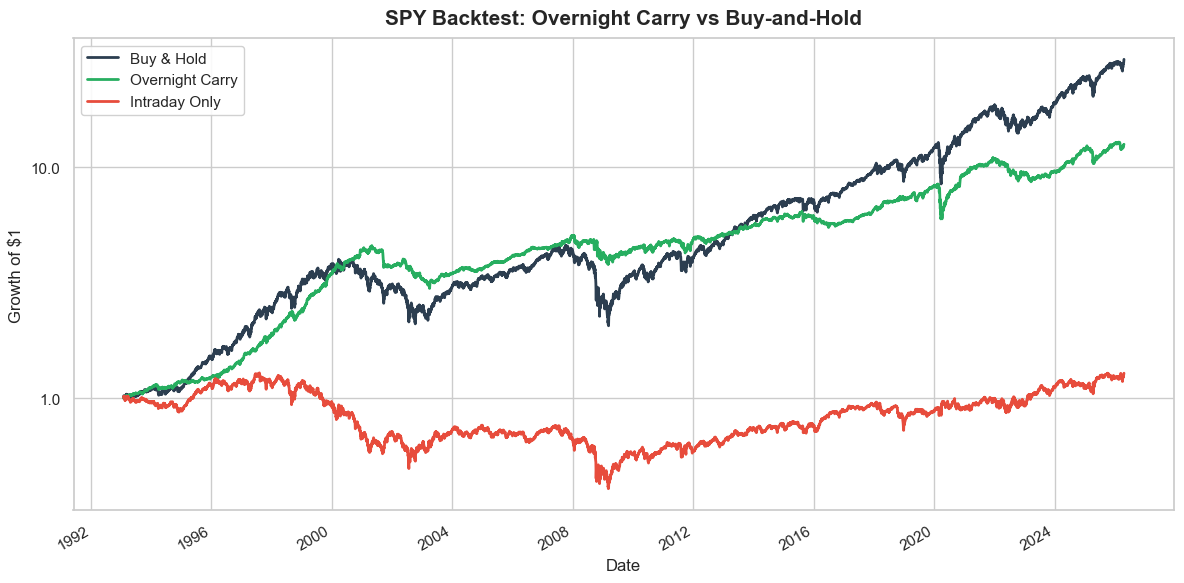

In [16]:
# Plot cumulative performance
import seaborn as sns
import matplotlib.ticker as ticker

# Apply global styling
sns.set_theme(style="whitegrid")
custom_colors = ['#2c3e50', '#27ae60', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
performance.plot(ax=ax, linewidth=2, color=custom_colors)

ax.set_title('SPY Backtest: Overnight Carry vs Buy-and-Hold', fontsize=15, fontweight='bold', pad=10)
ax.set_ylabel('Growth of $1', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.tick_params(axis='both', labelsize=11)

plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

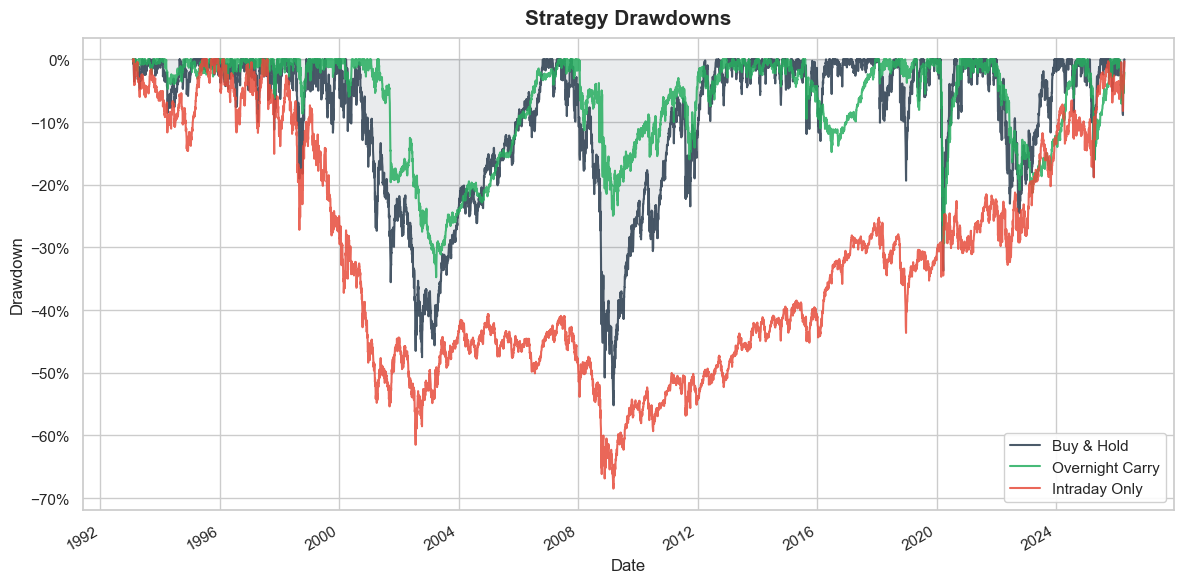

In [17]:
# Calculate and plot drawdowns
import matplotlib.ticker as mtick

drawdowns = pd.DataFrame(index=performance.index)
for col in performance.columns:
    running_max = performance[col].cummax()
    drawdowns[col] = performance[col] / running_max - 1

fig, ax = plt.subplots(figsize=(12, 6))
drawdowns.plot(ax=ax, linewidth=1.5, alpha=0.85, color=custom_colors)

ax.set_title('Strategy Drawdowns', fontsize=15, fontweight='bold', pad=10)
ax.set_ylabel('Drawdown', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.tick_params(axis='both', labelsize=11)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Fill under the Buy & Hold curve for visual reference
ax.fill_between(drawdowns.index, drawdowns['Buy & Hold'], 0, alpha=0.1, color='#2c3e50')

plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

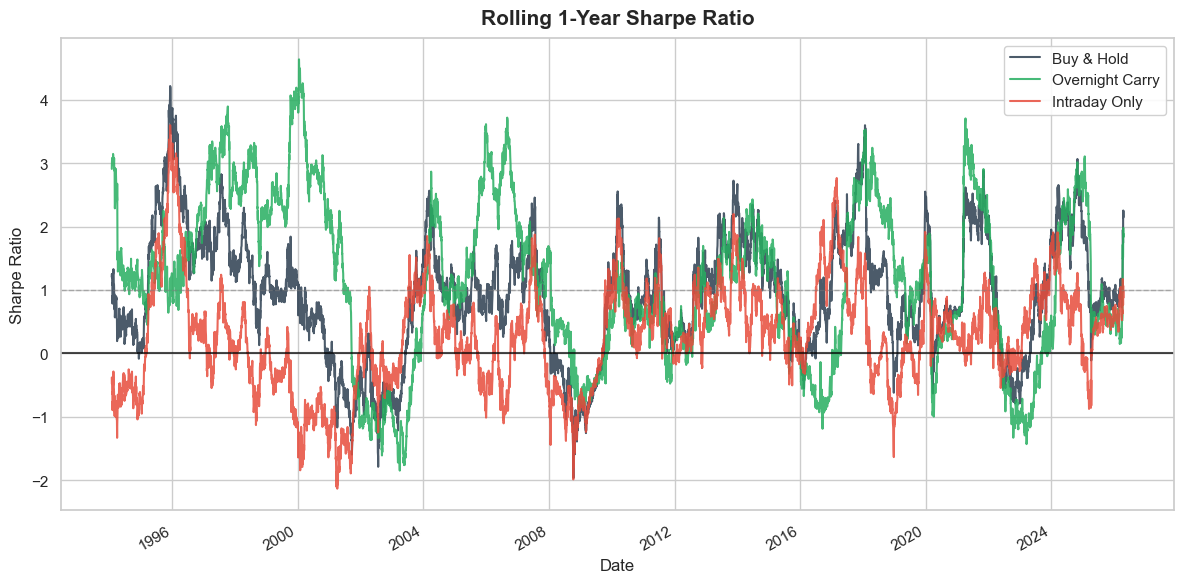

In [18]:
# Rolling 1-Year Sharpe Ratio
rolling_window = 252

rolling_sharpe = pd.DataFrame(index=performance.index)
# Map performance columns to data return columns
col_map = {
    'Buy & Hold': 'buy_hold_return',
    'Overnight Carry': 'overnight_return',
    'Intraday Only': 'intraday_return'
}

for perf_col, ret_col in col_map.items():
    mean_ret = data[ret_col].rolling(rolling_window).mean()
    std_ret = data[ret_col].rolling(rolling_window).std()
    rolling_sharpe[perf_col] = (mean_ret / std_ret) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))
rolling_sharpe.plot(ax=ax, linewidth=1.5, alpha=0.85, color=custom_colors)

ax.set_title('Rolling 1-Year Sharpe Ratio', fontsize=15, fontweight='bold', pad=10)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.tick_params(axis='both', labelsize=11)

# Emphasize the 0 and 1 lines
ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axhline(1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# Inspect contribution of overnight vs intraday returns
contribution = pd.DataFrame({
    'Overnight annualized mean': [data['overnight_return'].mean() * 252],
    'Intraday annualized mean': [data['intraday_return'].mean() * 252],
    'Buy & Hold annualized mean': [data['buy_hold_return'].mean() * 252],
    'Overnight std annualized': [data['overnight_return'].std() * np.sqrt(252)],
    'Intraday std annualized': [data['intraday_return'].std() * np.sqrt(252)],
    'Buy & Hold std annualized': [data['buy_hold_return'].std() * np.sqrt(252)],
})

contribution.T

,0
Overnight annualized mean,0.081829
Intraday annualized mean,0.018838
Buy & Hold annualized mean,0.118696
Overnight std annualized,0.106310
Intraday std annualized,0.152447
Buy & Hold std annualized,0.186016


In [9]:
# Monthly return comparison
monthly = pd.DataFrame({
    'Buy & Hold': (1 + data['buy_hold_return']).resample('ME').prod() - 1,
    'Overnight Carry': (1 + data['overnight_return']).resample('ME').prod() - 1,
    'Intraday Only': (1 + data['intraday_return']).resample('ME').prod() - 1,
})

monthly.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
Buy & Hold,0.009373,0.042541,-0.165187,-0.015464,0.013567,0.036655,0.126983
Overnight Carry,0.006715,0.026798,-0.196958,-0.004057,0.008168,0.020009,0.115505
Intraday Only,0.001255,0.036111,-0.156976,-0.020636,0.003420,0.024029,0.121380


## Interpretation guide

- If **Overnight Carry** outperforms **Buy & Hold**, it suggests a substantial portion of SPY's long-run return accrued outside regular cash trading hours.
- **Intraday Only** is included as a decomposition check and often contrasts sharply with overnight performance in index ETFs.
- For a production-quality strategy assessment, the next steps would be to include trading frictions, test subperiod stability, and compare against futures or index data.